In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [195]:
def low_pass_coefs(fc, Q=1, fs=44100):
    w0 = 2 * np.pi * fc / fs
    alpha = np.sin(w0) / (2 * Q)

    b0 = (1 - np.cos(w0)) / 2
    b1 = 1 - np.cos(w0)
    b2 = (1 - np.cos(w0)) / 2
    a0 = 1 + alpha
    a1 = -2 * np.cos(w0)
    a2 = 1 - alpha

    return np.array([b0, b1, b2, a0, a1, a2])

def low_pass_coefs_fpga(fc, k, fs=44100):
    w0 = 2 * np.pi * fc / fs

    b0 = (1 - np.cos(w0)) / 2
    b1 = 1 - np.cos(w0)
    b2 = (1 - np.cos(w0)) / 2
    a0 = 2**k/(2**k-1)
    a1 = -2 * np.cos(w0)
    a2 = (2**k-2)/(2**k-1)

    b0 /= a0
    b1 /= a0
    b2 /= a0
    a1 /= a0
    a2 /= a0

    return np.array([b0, b1, b2, 1, a1, a2])

def H(z, coefs):
    b0, b1, b2, a0, a1, a2 = coefs
    return (b0 + b1*z**(-1) + b2*z**(-2)) / (a0 + a1*z**(-1) + a2*z**(-2))

3.9479968572755832


C:\Users\Silvan\AppData\Local\Temp\ipykernel_22636\2806196338.py:20: RuntimeWarning: divide by zero encountered in log10
  plt.semilogx(freqs, 20*np.log10(np.abs(Hz)))
C:\Users\Silvan\AppData\Local\Temp\ipykernel_22636\2806196338.py:23: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 10000)


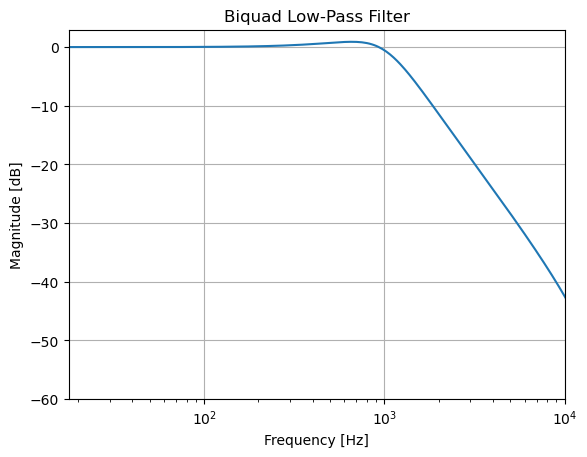

In [196]:
fs = 50000

freqs = np.linspace(0, fs/2, 1000)
z = np.exp(1j * 2 * np.pi * freqs / fs)

fc = 1000
k = 6
n = 2**k-1
Q = 0.5*n*np.sin(2*np.pi*fc/fs)
#k = 6
#m = 2**k-1
#Q = 0.5*np.sin(2*np.pi*fc/fs)/(2**k/m-1)
print(Q)

coefs = low_pass_coefs_fpga(fc, k=4, fs=fs)
#coefs = low_pass_coefs(fc, Q=8, fs=fs)

Hz = H(z, coefs)

plt.semilogx(freqs, 20*np.log10(np.abs(Hz)))

plt.ylim(-60, 3)
plt.xlim(0, 10000)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude [dB]')
plt.title('Biquad Low-Pass Filter')
plt.grid(True)
plt.show()

In [197]:
coefs_raw = low_pass_coefs_fpga(fc, k=4, fs=fs)
coefs = np.round(coefs_raw*2**21)
print(coefs_raw)
print(coefs)

[ 0.00369623  0.00739247  0.00369623  1.         -1.86021506  0.875     ]
[    7752.    15503.     7752.  2097152. -3901154.  1835008.]


In [ ]:
coefs = low_pass_coefs_fpga(fc, k=2, fs=fs)


def H(z, coefs):
    b0, b1, b2, a0, a1, a2 = coefs
    return (b0 + b1*z**(-1) + b2*z**(-2)) / (a0 + a1*z**(-1) + a2*z**(-2))

x = np.linspace(-1.1, 1.1, 1000)
X, Y = np.meshgrid(x, x)
Z = X + 1j*Y

phase = np.linspace(0, 2*np.pi, 100)
xc = np.cos(phase)
yc = np.sin(phase)

Hz = H(Z, coefs)

plt.figure(figsize=(5, 4))
#plt.contour(X, Y, np.abs(Hz), cmap='viridis', levels=500)
plt.pcolormesh(X, Y, np.log(np.abs(Hz)), cmap='viridis', vmin=-30, vmax=0)
plt.plot(xc, yc, 'k-.', linewidth=2)
plt.colorbar(label='Magnitude')
plt.xlabel('Real part')
plt.ylabel('Imaginary par')
plt.title('Biquad Low-Pass Filter')
plt.show()


SyntaxError: invalid syntax (438895571.py, line 2)

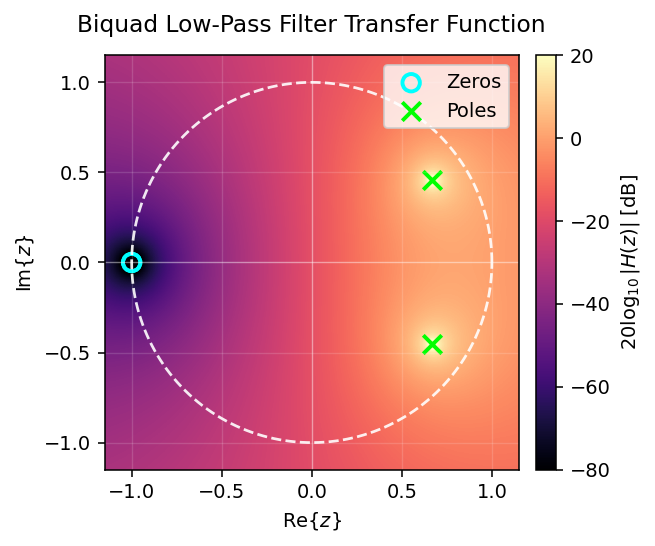

In [252]:
coefs = low_pass_coefs_fpga(1000, k=2, fs=fs)
coefs = low_pass_coefs(5000, Q=0.707*2, fs=fs)


def H(z, coefs):
    b0, b1, b2, a0, a1, a2 = coefs
    return (b0 + b1*z**(-1) + b2*z**(-2)) / (a0 + a1*z**(-1) + a2*z**(-2))

# Grid in the z-plane
n = 1000
x = np.linspace(-1.15, 1.15, n)
X, Y = np.meshgrid(x, x)
Z = X + 1j * Y

# Transfer function
Hz = H(Z, coefs)

# Magnitude in dB
mag_db = 20 * np.log10(np.abs(Hz))

# Avoid ugly infinities near poles / zeros
mag_db = np.nan_to_num(mag_db, nan=-120, posinf=120, neginf=-120)
mag_db = np.clip(mag_db, -80, 20)

# Unit circle
theta = np.linspace(0, 2*np.pi, 600)
unit_x = np.cos(theta)
unit_y = np.sin(theta)

# Poles and zeros
b0, b1, b2, a0, a1, a2 = coefs

zeros = np.roots([b0, b1, b2])
poles = np.roots([a0, a1, a2])

fig, ax = plt.subplots(figsize=(5, 4), dpi=140)

im = ax.pcolormesh(
    X, Y, mag_db,
    shading="auto",
    cmap="magma",
    vmin=-80,
    vmax=20
)

# Unit circle
ax.plot(unit_x, unit_y, color="white", linestyle="--", linewidth=1.4, alpha=0.9)

# Axes through origin
ax.axhline(0, color="white", linewidth=0.7, alpha=0.35)
ax.axvline(0, color="white", linewidth=0.7, alpha=0.35)

# Poles and zeros
ax.scatter(
    zeros.real, zeros.imag,
    marker="o",
    s=80,
    facecolors="none",
    edgecolors="cyan",
    linewidths=2,
    label="Zeros"
)

ax.scatter(
    poles.real, poles.imag,
    marker="x",
    s=90,
    color="lime",
    linewidths=2,
    label="Poles"
)

# Labels and styling
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-1.15, 1.15)

ax.set_xlabel(r"$\mathrm{Re}\{z\}$")
ax.set_ylabel(r"$\mathrm{Im}\{z\}$")
ax.set_title("Biquad Low-Pass Filter Transfer Function", pad=12)

ax.grid(color="white", alpha=0.15, linewidth=0.7)
ax.legend(loc="upper right", frameon=True)

cbar = fig.colorbar(im, ax=ax, pad=0.03)
cbar.set_label(r"$20 \log_{10}|H(z)|$ [dB]")

plt.tight_layout()
plt.show()

In [194]:
fs = 50000
fc = 250

w = fc/fs
w*2**16

327.68